In [1]:
import netCDF4 as nc
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.path as mpath
import cartopy.feature as cfeature

import seaborn as sns
import matplotlib.colors as cols
from mpl_toolkits.basemap import Basemap

In [2]:
pwd

'/media/ub/Elements/iHESPplot/Paper3line'

In [3]:
iceyes = np.load('/media/ub/Elements/iHESPdata/ICE/smalliceallsumtime250-493.npy')
iceyes2 = np.load('/media/ub/Elements/iHESPdata/ICE/smalliceallsumtime495-650.npy')
ice = iceyes/1000000 # m^2 to km^2:q
ice2 = iceyes2/1000000 # m^2 to km^2
timeice=ice/10000000
timeice2=ice2/10000000
timei = np.hstack((timeice, timeice2))

arr = timei
window_size = 5

i = 0
# Initialize an empty list to store moving averages
moving_averages = []

# Loop through the array t o
#consider every window of size 3
while i < len(arr) - window_size + 1:

    # Calculate the average of current window
    window_average = round(np.sum(arr[
      i:i+window_size]) / window_size, 2)
    
    # Store the average of current
    # window in moving average list
    moving_averages.append(window_average)
    
    # Shift window to right by one position
    i += 1

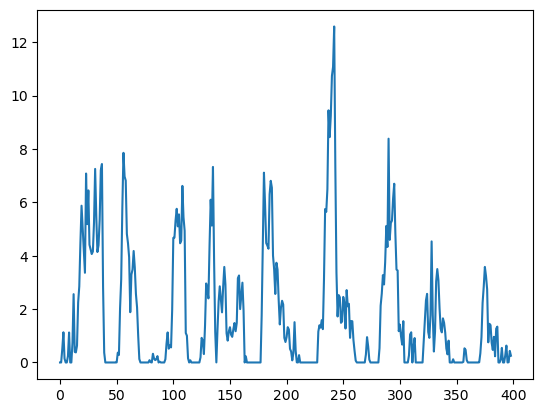

In [4]:
plt.plot(timei)

In [5]:
len(moving_averages)

395

In [6]:
ccc = []
for index, i in enumerate(moving_averages[:246]):
    if i==0 :
        ccc.append(index)

In [7]:
ddd222 = []
for index, i in enumerate(moving_averages[:246]):
    if i > 3.5 :
        ddd222.append(index)

In [8]:
ddd = []
for index, i in enumerate(moving_averages[:246]):
    if 2<i<3.5 :
        ddd.append(index+3)

In [9]:
eee = []
for index, i in enumerate(moving_averages[:246]):
    if 2<i<3.5 :
        eee.append(index)

In [10]:
eee

[14,
 15,
 37,
 51,
 60,
 61,
 62,
 63,
 64,
 65,
 97,
 98,
 109,
 128,
 134,
 135,
 139,
 140,
 141,
 142,
 143,
 144,
 154,
 155,
 156,
 157,
 158,
 176,
 188,
 189,
 190,
 191,
 192,
 193,
 230,
 231,
 243,
 244]

In [11]:
openocean = np.load('/media/ub/Elements/iHESPplot/SWMT/openoceandeep176runing.npy')
openoceantime = np.load('/media/ub/Elements/iHESPplot/SWMT/openoceandeeptime176runing.npy')

In [12]:
193+250

443

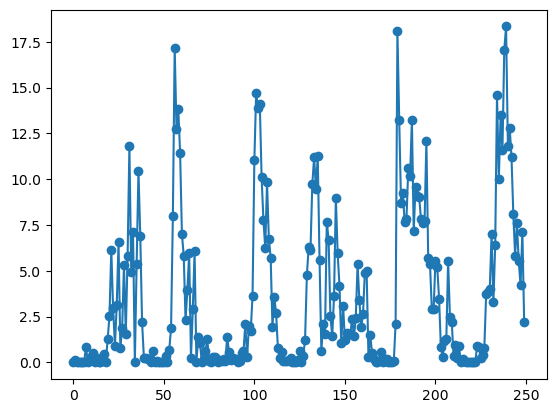

In [13]:
plt.plot(openoceantime[:],marker='o')

In [14]:
len(openocean)

246

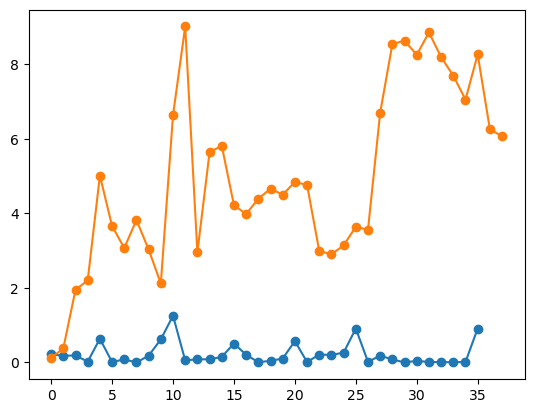

In [15]:
plt.plot(openoceantime[ccc],marker='o')
plt.plot(openocean[eee[:]],marker='o')

In [16]:
DSW1 = np.load('/media/ub/Elements/iHESPplot/iceplot/cross1000sigma1/weDSW1plusplusrun.npy')
DSW1time = np.load('/media/ub/Elements/iHESPplot/iceplot/cross1000sigma1/we2timeplusplusrun.npy')

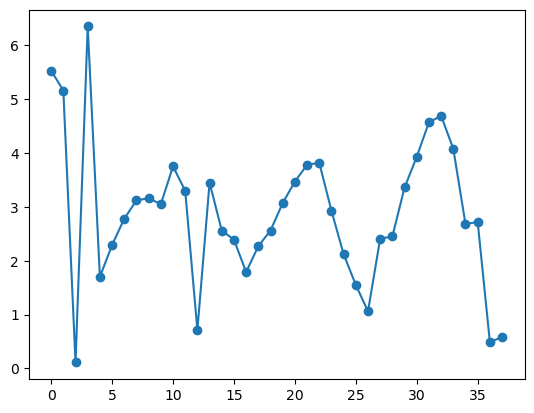

In [17]:
plt.plot(DSW1[eee[:]],marker='o')

In [18]:
WSPsmall = np.load('/media/ub/Elements/iHESPplot/iceplot/smallMRP.npy')
WSPbigger = np.load('/media/ub/Elements/iHESPplot/iceplot/smallWSP.npy')

In [19]:
openocean.shape

(246,)

In [20]:
pwd

'/media/ub/Elements/iHESPplot/Paper3line'

In [21]:
SWMTs = np.load('/media/ub/Elements/iHESPplot/SWMT/SWMTsurface.npy')
SWMTsall = np.load('/media/ub/Elements/iHESPplot/SWMT/SWMTsurfacealltime.npy')

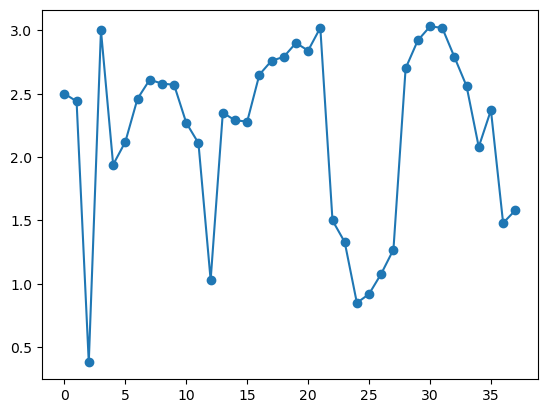

In [22]:
plt.plot(SWMTs[eee[:]],marker='o')

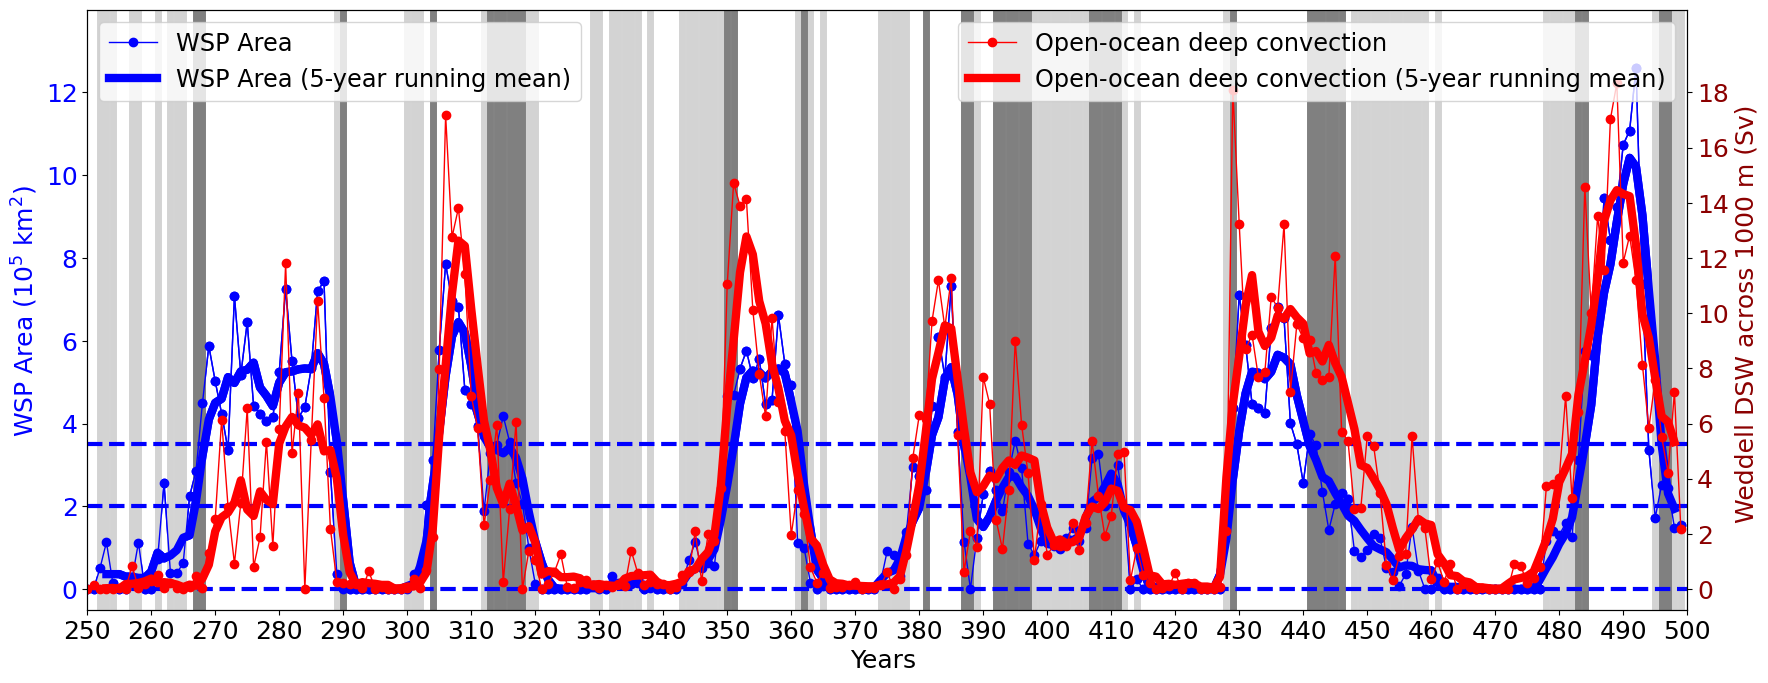

In [23]:
fig = plt.figure(figsize=(20,20), dpi=100)
my_font = { 'size':'18'}
################################################################
################################################################
t = np.arange(3,249,1)
ax1 = fig.add_axes([0.1, 0.9, 0.8, 0.3],
                   xticklabels=[])
ax1.plot(timei[:250],color='blue',marker='o',linewidth=1,label='WSP Area')

ax1.plot(t,moving_averages[:246],color='blue',linewidth=6,label='WSP Area (5-year running mean)')
plt.legend(loc='upper left',fontsize='xx-large')
#plt.legend()


plt.vlines(WSPsmall, -1, 22, linestyles="solid", colors="lightgrey" ,linewidth=5)
plt.vlines(ddd[:], -1, 22, linestyles="solid", colors="grey" ,linewidth=5)
plt.hlines(0,0,250,linestyles="dashed", colors="blue",linewidth=3)
plt.hlines(2,0,250,linestyles="dashed", colors="blue",linewidth=3)
plt.hlines(3.5,0,250,linestyles="dashed", colors="blue",linewidth=3)
ax1.plot(timei[:250],color='blue',marker='o',linewidth=1,label='WSP Area')

ax1.plot(t,moving_averages[:246],color='blue',linewidth=6,label='WSP Area (5-year running mean)')
plt.axis("tight")
plt.yticks(np.arange(0,14,2), ['0','2','4','6','8','10','12'],**my_font,color='blue')
plt.ylabel('WSP Area (10$^5$ km$^2$) ',**my_font,color='blue')
#plt.title('Weddell DSW overflow across 1000m isodepth ($\sigma$$_1$>32.58)',**my_font)
plt.xticks(np.arange(0,260,10), ['250','260','270','280','290','300','310','320','330','340','350','360','370','380','390','400','410','420','430','440','450','460','470','480','490','500'],**my_font)
plt.xlabel('Years ',**my_font)
ax1.set(ylim=(-0.5, 14),xlim=(0, 250))


#plt.vlines(49, -1, 20, linestyles="solid", colors="green" ,linewidth=3)

#plt.vlines(93, -1, 20, linestyles="solid", colors="green" ,linewidth=3)
#plt.vlines(124, -1, 20, linestyles="solid", colors="green" ,linewidth=3)
#plt.vlines(177, -1, 20, linestyles="solid", colors="green" ,linewidth=3)
#plt.vlines(228, -1, 20, linestyles="solid", colors="green" ,linewidth=3)

ax2 = ax1.twinx()

ax2.plot(openoceantime,color='red',marker='o',linewidth=1,label='Open-ocean deep convection')

ax2.plot(t,openocean[:246],color='red',linewidth=6,label='Open-ocean deep convection (5-year running mean)')
plt.legend(loc='upper left',fontsize='xx-large')



plt.legend(loc='upper right',fontsize='xx-large')
plt.yticks(np.arange(0,20,2), ['0','2','4','6','8','10','12','14','16','18'],**my_font,color='darkred')
plt.ylabel('Weddell DSW across 1000 m (Sv) ',**my_font,color='darkred')
#plt.ylabel('Weddell DSW across  ',**my_font,color='darkred')
#plt.hlines(6,0,250,linestyles="dashed", colors="red",linewidth=3)
#plt.hlines(3, 0, 250, linestyles="dashed", colors="darkgreen" ,linewidth=3)
ax2.set(ylim=(-0.75, 21),xlim=(0, 250))

plt.savefig("Fig3test222.png",bbox_inches='tight')

In [24]:
openocean222 = openocean[:246]

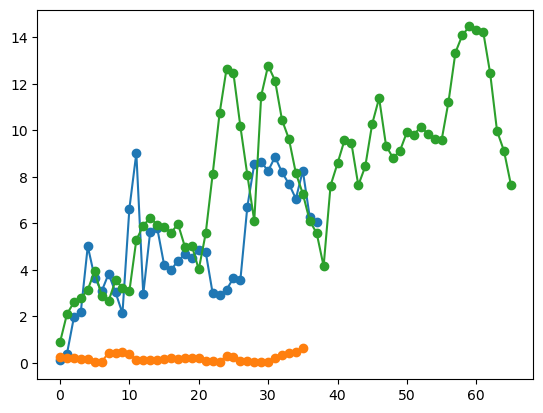

In [25]:
aircho235 = openocean[eee[:]]
plt.plot(openocean[eee[:]],marker='o')
aircho0 = openocean[ccc[:]]
plt.plot(openocean[ccc[:]],marker='o')
aircho35 = openocean[ddd222[:]]
plt.plot(openocean[ddd222[:]],marker='o')

In [26]:
np.mean(aircho235)

4.9331578947368415

In [27]:
np.std(aircho235)

2.3645663953941205

In [28]:
np.mean(aircho0)

0.20194444444444443

In [29]:
np.std(aircho0)

0.15068029887525375

In [30]:
np.mean(aircho35)

7.984393939393939

In [31]:
np.std(aircho35)

3.453147062129058